In [ ]:
head
column name
datatypes
train test split data
encoding
decision tree classifier
pruning
check alpha values
decision tree
confusion matrix
accuracy


In [37]:
from google.colab import files

uploaded = files.upload()  # This opens a file upload dialog


Saving processed.cleveland.data to processed.cleveland (1).data


In [38]:
import pandas as pd

# Load the dataset (assuming it has been uploaded or mounted correctly)
df = pd.read_csv("processed.cleveland.data", header=None)  # No headers in this dataset

# Display the first 5 rows
print(df.head())


     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0


In [39]:
# Assign column names
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df.columns = column_names



In [40]:
# Display the data types of each column
print(df.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


In [41]:
import numpy as np

from sklearn.model_selection import train_test_split

# Handle missing values (replace '?' with NaN and drop rows)
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

# Convert all columns to numeric
df = df.astype(float)

# Split features (X) and target (y)
X = df.drop(columns=["target"])  # Features
y = df["target"].astype(int)  # Convert target to integer

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully.")

Data split successfully.


In [42]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
encoder = LabelEncoder()

# Encode the target variable (if not already an integer)
y = encoder.fit_transform(y)

print("Encoding completed.")


Encoding completed.


In [43]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)

# Train (fit) the model
clf.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")


Decision Tree Classifier trained successfully.


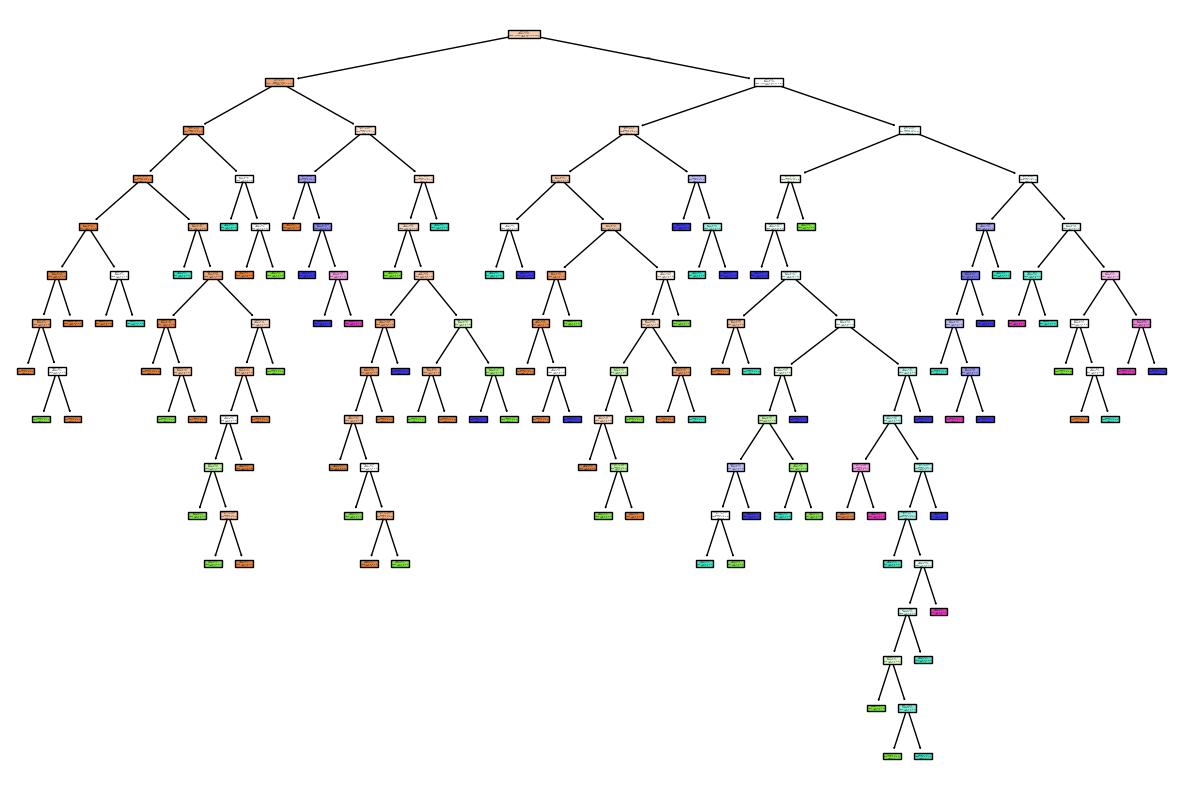

In [44]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

# Get unique target class labels using NumPy
class_names = [str(cls) for cls in np.unique(y)]

# Plot the decision tree
plt.figure(figsize=(15, 10))
plot_tree(clf, feature_names=X.columns, class_names=class_names, filled=True)
plt.show()


In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

clf_pruned=DecisionTreeClassifier(max_depth=5, random_state=42)
clf_pruned.fit(X_train, y_train)

y_pred = clf_pruned.predict(X_test)




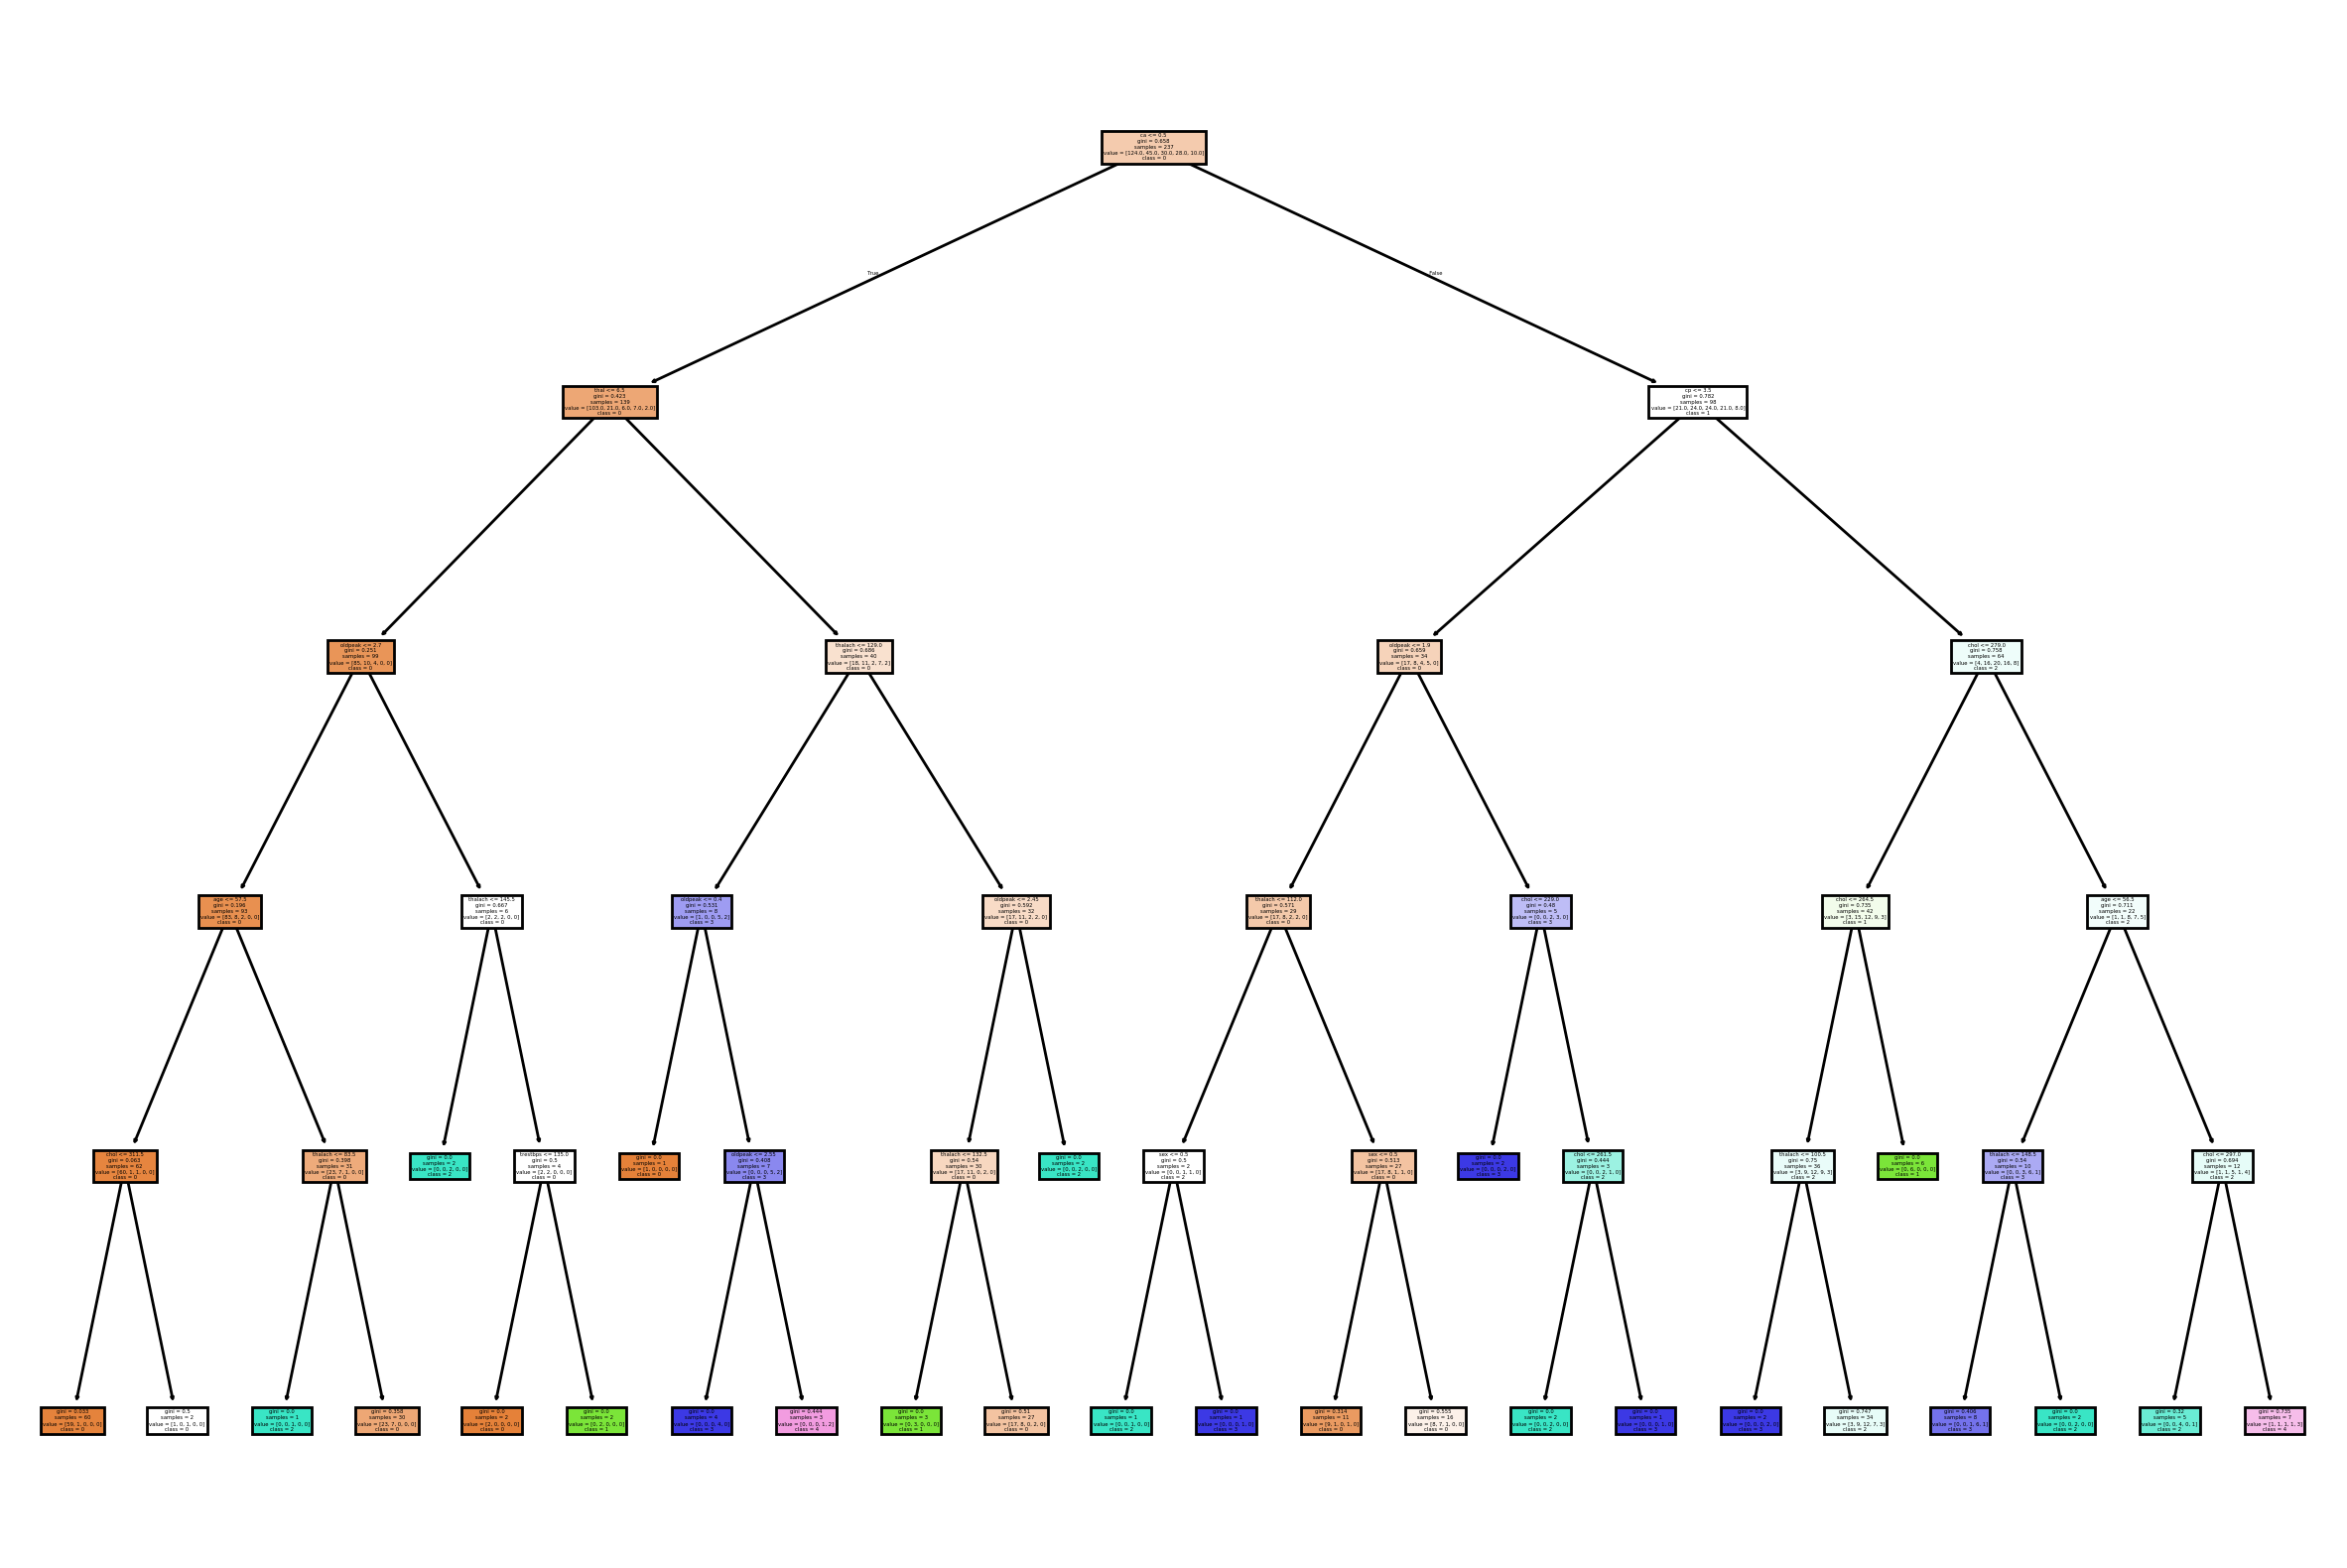

In [46]:
# Plot the pruned decision tree with higher dpi for better clarity
plt.figure(figsize=(15, 10), dpi=200)
plot_tree(clf_pruned, feature_names=X.columns, class_names=np.unique(y).astype(str), filled=True)
plt.show()

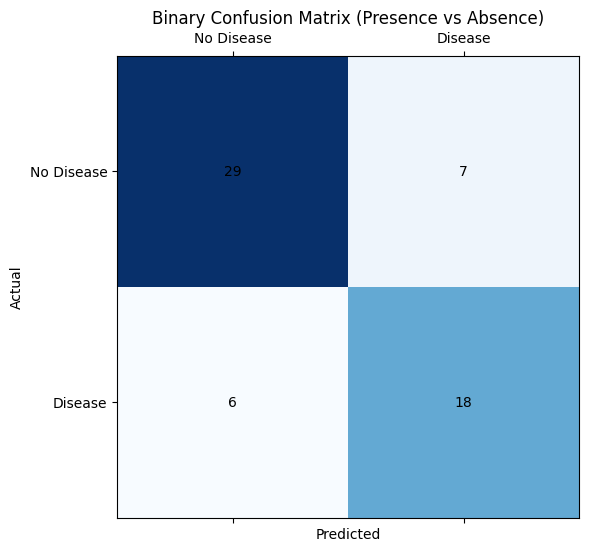

True Positive (TP): 18
True Negative (TN): 29
False Positive (FP): 7
False Negative (FN): 6


In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Binarize the target variable (y)
y_binary = np.where(y > 0, 1, 0)  # 0 for absence, 1 for presence

# Split the dataset into training and testing sets (using binary labels)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Train the decision tree with the binary classification target
clf_pruned.fit(X_train, y_train)

# Get predictions from the pruned decision tree
y_pred = clf_pruned.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract values for TP, TN, FP, FN
TP = cm[1, 1]  # True Positive
TN = cm[0, 0]  # True Negative
FP = cm[0, 1]  # False Positive
FN = cm[1, 0]  # False Negative

# Create a figure to display the confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))

# Display the confusion matrix values
conf_matrix = np.array([[TN, FP],
                        [FN, TP]])

# Plot the confusion matrix using imshow
cax = ax.matshow(conf_matrix, cmap="Blues")

# Add annotations for each cell in the matrix
for (i, j), value in np.ndenumerate(conf_matrix):
    ax.text(j, i, f'{value}', ha='center', va='center', color='black')

# Set labels and title
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Disease", "Disease"])
ax.set_yticklabels(["No Disease", "Disease"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Binary Confusion Matrix (Presence vs Absence)')

# Display the plot
plt.show()

# Print out TP, TN, FP, FN
print(f"True Positive (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")



In [51]:
from sklearn.metrics import accuracy_score

# Get accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"Accuracy of the Decision Tree Classifier: {accuracy:.4f}")


Accuracy of the Decision Tree Classifier: 0.6000


Alpha values for pruning:
[0.         0.00276606 0.00361664 0.00389484 0.00401751 0.00543835
 0.00562588 0.00562588 0.00562588 0.00562588 0.0060654  0.00664518
 0.00761838 0.00766526 0.00843882 0.00889252 0.00972473 0.01350211
 0.01487036 0.01593999 0.02109705 0.03586498 0.0401355  0.13456628]
Impurities for each alpha:
[0.         0.00829817 0.02276472 0.0305544  0.03858942 0.05490447
 0.07178211 0.08865975 0.0999115  0.11116326 0.12329406 0.13658442
 0.16705793 0.18238845 0.19082727 0.19971979 0.20944452 0.23644874
 0.2513191  0.26725909 0.28835614 0.32422111 0.36435662 0.49892289]
Pruned Decision Tree Accuracy (ccp_alpha=0.005438349742147208): 0.82


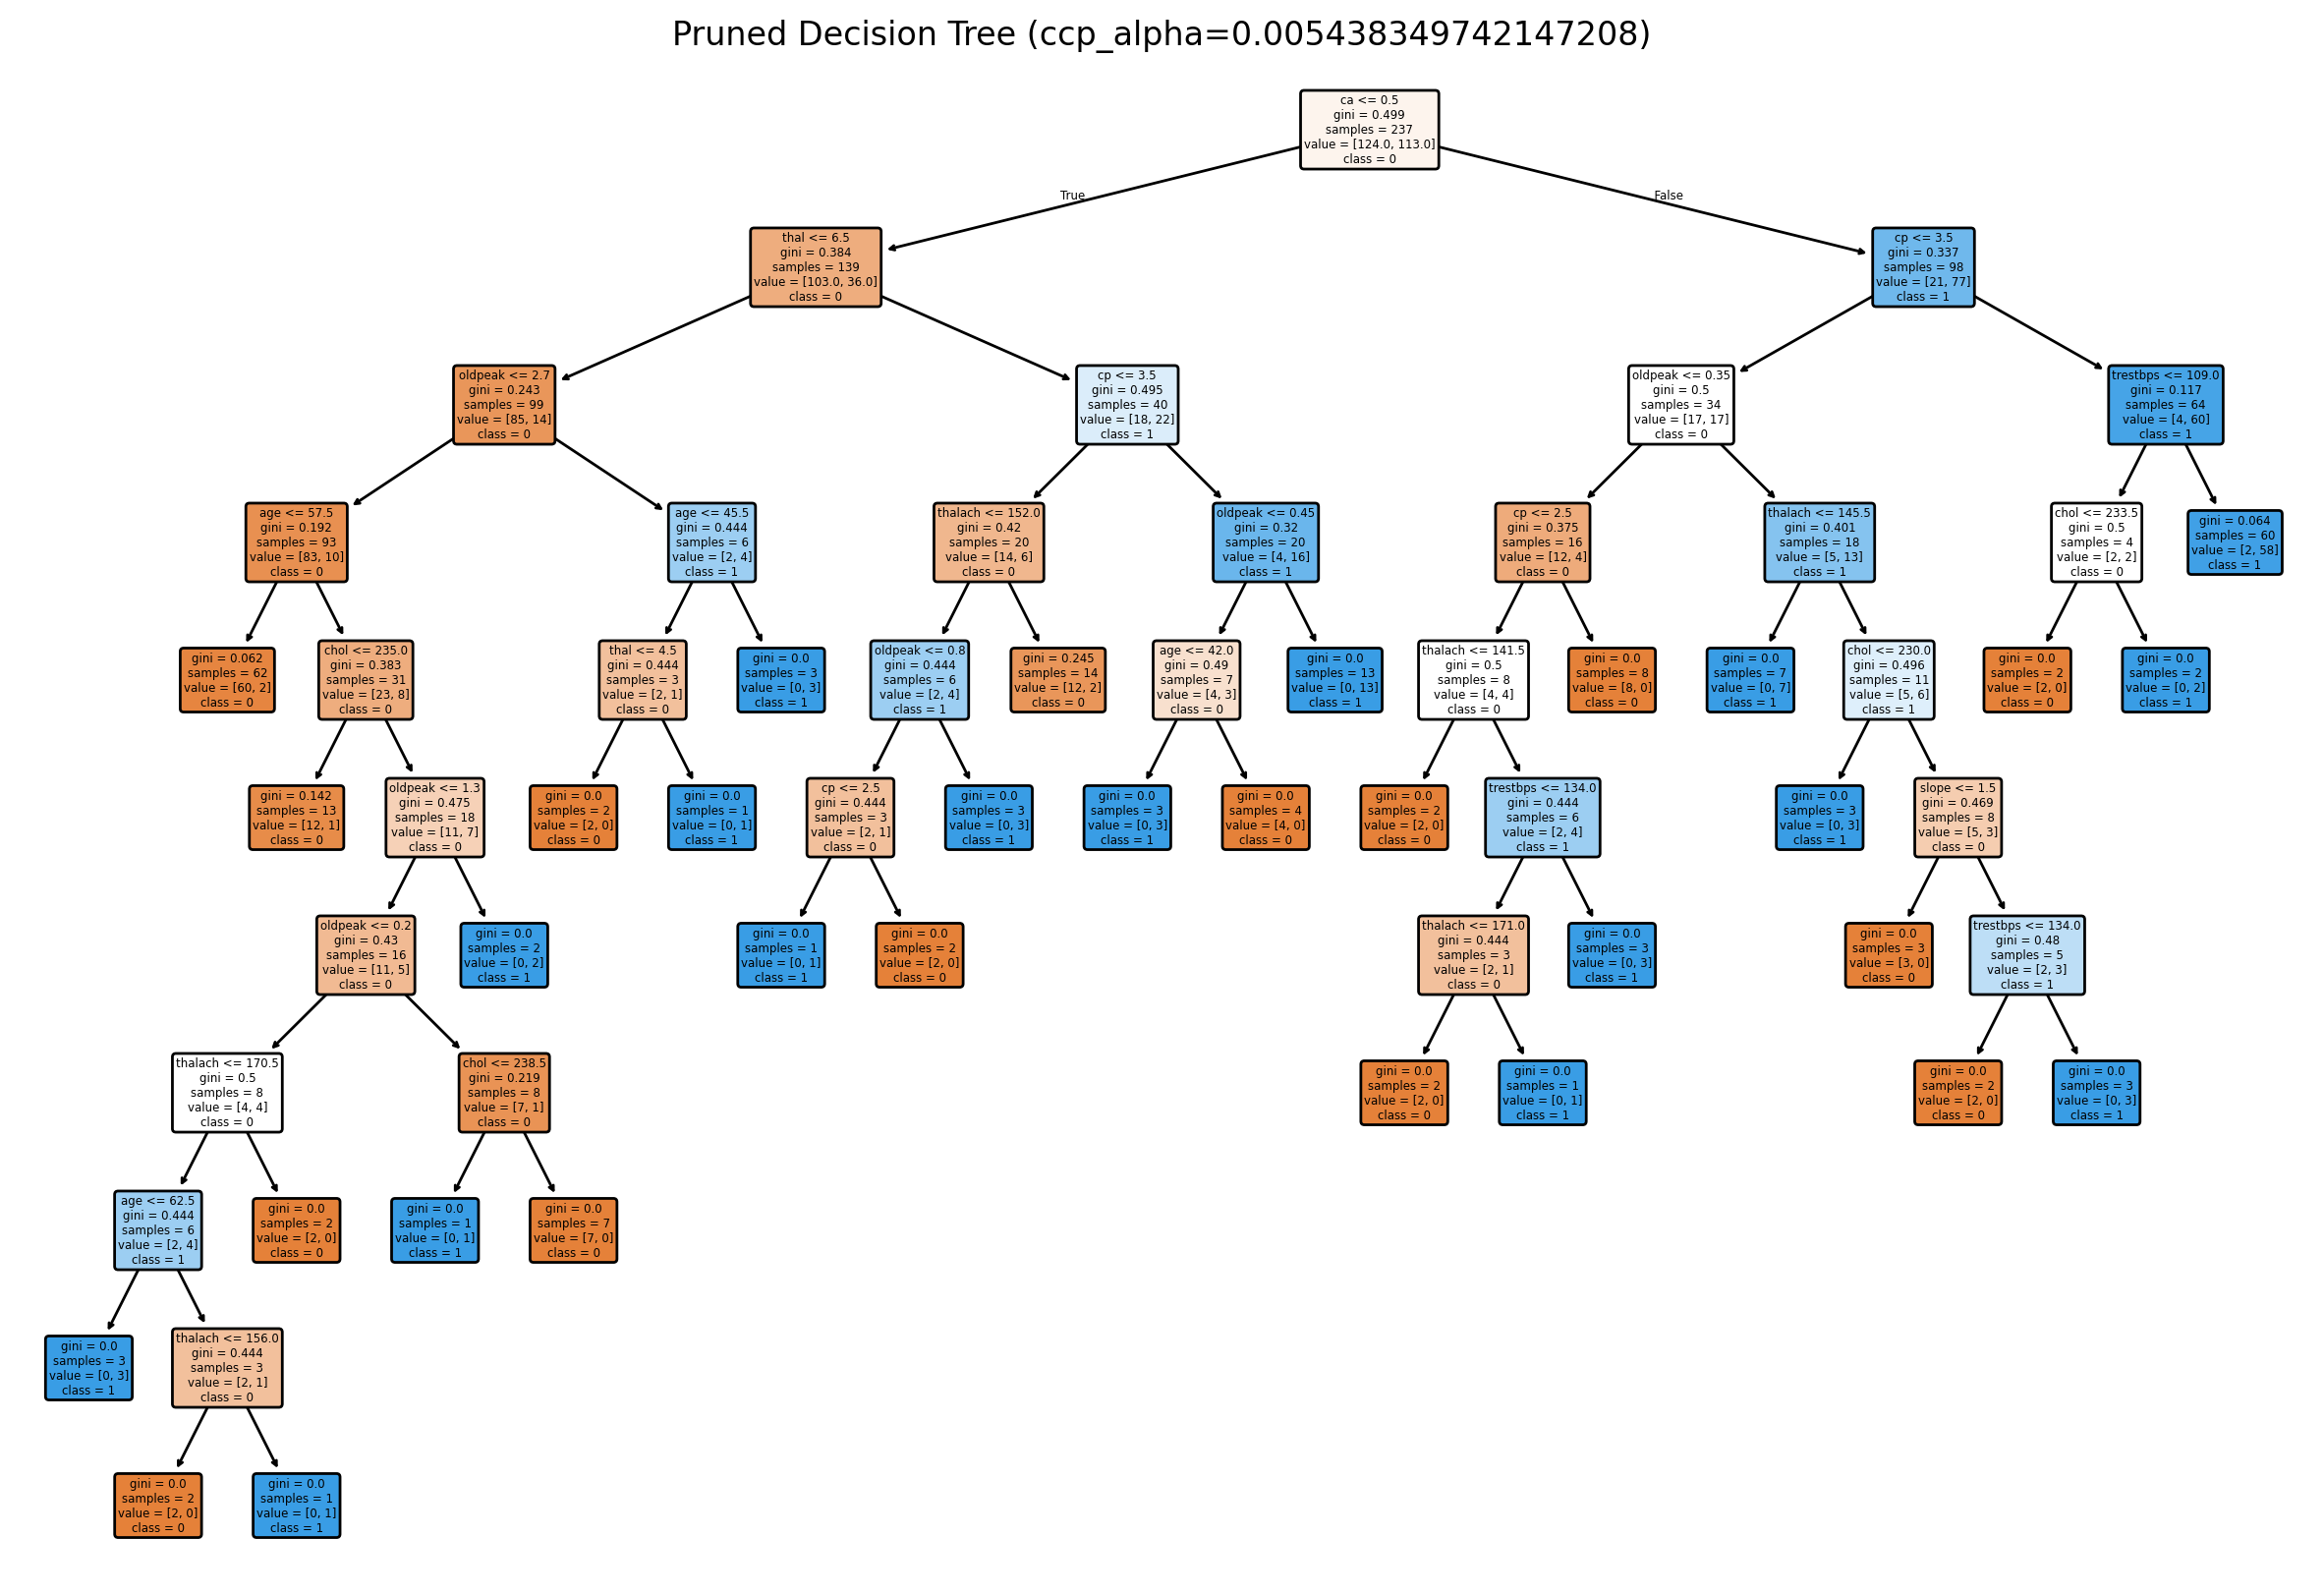

In [53]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Train the decision tree without pruning first
clf_full_tree = DecisionTreeClassifier(random_state=42)
clf_full_tree.fit(X_train, y_train)

# Step 2: Get the cost-complexity pruning path
path = clf_full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Print the alpha values and their corresponding impurities
print("Alpha values for pruning:")
print(ccp_alphas)
print("Impurities for each alpha:")
print(impurities)

# Step 3: Train pruned decision trees using different alpha values
# Selecting an optimal alpha value
optimal_alpha = ccp_alphas[5]  # Example alpha value, adjust based on analysis

clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_alpha)
clf_pruned.fit(X_train, y_train)

# Step 4: Make predictions and evaluate accuracy
y_pred_pruned = clf_pruned.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print(f"Pruned Decision Tree Accuracy (ccp_alpha={optimal_alpha}): {accuracy_pruned:.2f}")

# Step 5: Display the pruned decision tree
plt.figure(figsize=(15, 10), dpi=200)
plot_tree(clf_pruned, feature_names=X.columns, class_names=[str(cls) for cls in np.unique(y)], filled=True, rounded=True)
plt.title(f"Pruned Decision Tree (ccp_alpha={optimal_alpha})")
plt.show()
